In [2]:
import numpy as np
import matplotlib.pyplot as plt
import chipwhisperer as cw
import scipy
import scipy.stats

In [2]:
#Snow-V function
def MAKEU16(a, b):
    return ((a << 8) | b)

def mul_x(v, c):
    if v & 0x8000:
        return (((v << 1) ^ c) & 0xffff)
    else:
        return ((v << 1) & 0xffff)
        
def mul_x_inv(v, d):
    if v & 0x0001:
        return (((v >> 1) ^ d) & 0xffff)
    else:
        return ((v >> 1) & 0xffff)

In [3]:
key1 = np.load('key3.npy')
print(key1)

[255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255 255
 255 255 255 255 255 255 255 255 255 255 255 255 255 255]


size of u_hyp (10, 256)
size of HW_u_hyp (10, 256)


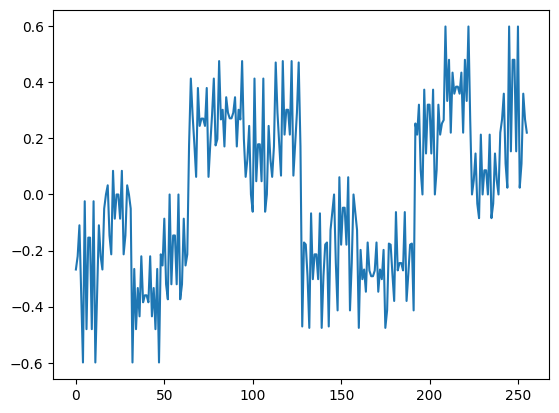

In [3]:
key1 = np.load('key3.npy')
A1 = [0] * 16
B1 = [0] * 16
HW = [(bin(n)).count("1") for n in range(0, 131072)]
HW_u1 = []
u_hyp1 = [] #for key varying from(0-256)
HW_u_hyp1 = []
num1 = 10
iv1 = np.load('iv3.npy')
iv1 = np.array(iv1[:num1])
trace_array1 = np.load('traces_array3.npy')
trace_array1 = np.array(trace_array1[:num1])
u_captured1 = np.load('u_captured3.npy')
u_captured1 = np.array(u_captured1[:num1])
for j1 in range(num1):
    for i1 in range(8):
        B1[i1]     = 0x0000
        B1[i1 + 8] = MAKEU16(key1[2 * i1 + 17], key1[2 * i1 + 16])
        
B1 = np.array(B1)
for j1 in range(num1):
    A1 = [0] * 16
    for i1 in range(8):
        A1[i1]     = MAKEU16(iv1[j1][2 * i1 + 1], iv1[j1][2 * i1])
        A1[i1 + 8] = MAKEU16(key1[2 * i1 + 1], key1[2 * i1])
    A1 = np.array(A1)

for u1 in u_captured1:
    HW_u1.append(HW[u1])
    
for j1 in range(num1):
    sub_u_hyp1 = []
    for A1[8] in range(0, 256):
        for i1 in range(8):
            A1[i1] = MAKEU16(iv1[j1][2 * i1 + 1], iv1[j1][2 * i1])
            #B[i] = 0x0000
        sub_u_hyp1.append(mul_x(A1[0], 0x990f) ^ A1[1] ^ mul_x_inv(A1[8], 0xcc87) ^ B1[0])    
    u_hyp1.append(sub_u_hyp1)
print("size of u_hyp",np.shape(u_hyp1))

for m in range(len(u_hyp1)):
    sub_HW_u_hyp1 = []
    for s in range(256):
        sub_HW_u_hyp1.append(('{0:08b}'.format(u_hyp1[m][s])[::-1][0:7]).count("1")) #Hamming weight of 1000 u [0:7] lower bits
    HW_u_hyp1.append(sub_HW_u_hyp1)
print("size of HW_u_hyp", np.shape(HW_u_hyp1))

samples_per_trace1 = np.shape(HW_u_hyp1)[1]
num_traces1 = np.shape(HW_u_hyp1)[0]

plt.figure()
hyp_pwr1 = np.array(HW_u1).reshape(-1,1)

traces_hyp_pwr1 = np.concatenate((HW_u_hyp1,hyp_pwr1), axis = 1)
    
correlation1 = np.corrcoef(traces_hyp_pwr1.T)
corr1 = correlation1[samples_per_trace1, :samples_per_trace1]
plt.plot(corr1)
plt.show()

In [4]:
print(corr1[255])

0.22041550751119357


size of u_hyp (25, 256)
size of HW_u_hyp (25, 256)


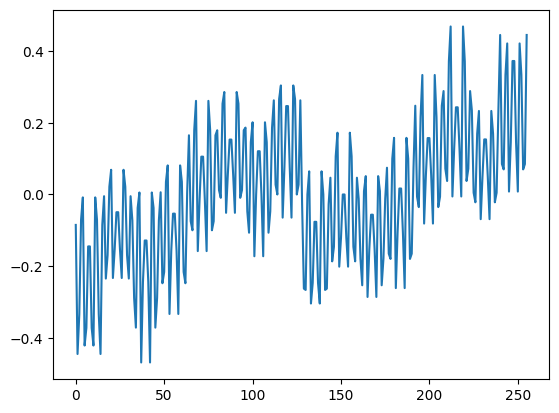

In [5]:
key2 = np.load('key3.npy')
A2 = [0] * 16
B2 = [0] * 16
HW = [(bin(n)).count("1") for n in range(0, 131072)]
HW_u2 = []
u_hyp2 = [] #for key varying from(0-256)
HW_u_hyp2 = []
num2 = 25
iv2 = np.load('iv3.npy')
iv2 = np.array(iv2[:num2])
trace_array2 = np.load('traces_array3.npy')
trace_array2 = np.array(trace_array2[:num2])
u_captured2 = np.load('u_captured3.npy')
u_captured2 = np.array(u_captured2[:num2])
for j1 in range(num2):
    for i1 in range(8):
        B2[i1]     = 0x0000
        B2[i1 + 8] = MAKEU16(key2[2 * i1 + 17], key2[2 * i1 + 16])
        
B2 = np.array(B2)
for j1 in range(num2):
    for i1 in range(8):
        A2[i1]     = MAKEU16(iv2[j1][2 * i1 + 1], iv2[j1][2 * i1])
        A2[i1 + 8] = MAKEU16(key2[2 * i1 + 1], key2[2 * i1])
    A2 = np.array(A2)

for u1 in u_captured2:
    HW_u2.append(HW[u1])
    
for j1 in range(num2):
    sub_u_hyp2 = []
    for A2[8] in range(0, 256):
        for i1 in range(8):
            A2[i1] = MAKEU16(iv2[j1][2 * i1 + 1], iv2[j1][2 * i1])
            #B[i] = 0x0000
        sub_u_hyp2.append(mul_x(A2[0], 0x990f) ^ A2[1] ^ mul_x_inv(A2[8], 0xcc87) ^ B2[0])    
    u_hyp2.append(sub_u_hyp2)
print("size of u_hyp",np.shape(u_hyp2))

for m in range(len(u_hyp2)):
    sub_HW_u_hyp2 = []
    for s in range(256):
        sub_HW_u_hyp2.append(('{0:08b}'.format(u_hyp2[m][s])[::-1][0:7]).count("1")) #Hamming weight of 1000 u [0:7] lower bits
    HW_u_hyp2.append(sub_HW_u_hyp2)
print("size of HW_u_hyp", np.shape(HW_u_hyp2))

samples_per_trace2 = np.shape(HW_u_hyp2)[1]
num_traces2 = np.shape(HW_u_hyp2)[0]

plt.figure()
hyp_pwr2 = np.array(HW_u2).reshape(-1,1)

traces_hyp_pwr2 = np.concatenate((HW_u_hyp2,hyp_pwr2), axis = 1)
    
correlation2 = np.corrcoef(traces_hyp_pwr2.T)
corr2 = correlation2[samples_per_trace2, :samples_per_trace2]
plt.plot(corr2)
plt.show()

In [6]:
print(corr2[1])

-0.44449112733354396


size of u_hyp (50, 256)
size of HW_u_hyp (50, 256)


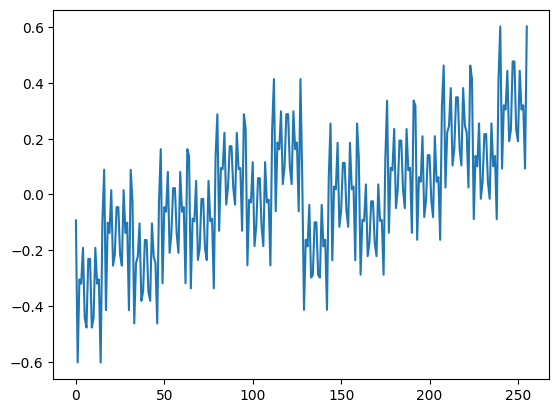

In [7]:
key3 = np.load('key3.npy')
A3 = [0] * 16
B3 = [0] * 16
HW = [(bin(n)).count("1") for n in range(0, 131072)]
HW_u3 = []
u_hyp3 = [] #for key varying from(0-256)
HW_u_hyp3 = []
num3 = 50
iv3 = np.load('iv3.npy')
iv3 = np.array(iv3[:num3])
trace_array3 = np.load('traces_array3.npy')
trace_array3 = np.array(trace_array3[:num3])
u_captured3 = np.load('u_captured3.npy')
u_captured3 = np.array(u_captured3[:num3])
for j1 in range(num3):
    for i1 in range(8):
        B3[i1]     = 0x0000
        B3[i1 + 8] = MAKEU16(key3[2 * i1 + 17], key3[2 * i1 + 16])
        
B3 = np.array(B3)
for j1 in range(num3):
    for i1 in range(8):
        A3[i1]     = MAKEU16(iv3[j1][2 * i1 + 1], iv3[j1][2 * i1])
        A3[i1 + 8] = MAKEU16(key3[2 * i1 + 1], key3[2 * i1])
    A3 = np.array(A3)

for u1 in u_captured3:
    HW_u3.append(HW[u1])
    
for j1 in range(num3):
    sub_u_hyp3 = []
    for A3[8] in range(0, 256):
        for i1 in range(8):
            A3[i1] = MAKEU16(iv3[j1][2 * i1 + 1], iv3[j1][2 * i1])
            #B[i] = 0x0000
        sub_u_hyp3.append(mul_x(A3[0], 0x990f) ^ A3[1] ^ mul_x_inv(A3[8], 0xcc87) ^ B3[0])    
    u_hyp3.append(sub_u_hyp3)
print("size of u_hyp",np.shape(u_hyp3))

for m in range(len(u_hyp3)):
    sub_HW_u_hyp3 = []
    for s in range(256):
        sub_HW_u_hyp3.append(('{0:08b}'.format(u_hyp3[m][s])[::-1][0:7]).count("1")) #Hamming weight of 1000 u [0:7] lower bits
    HW_u_hyp3.append(sub_HW_u_hyp3)
print("size of HW_u_hyp", np.shape(HW_u_hyp3))

samples_per_trace3 = np.shape(HW_u_hyp3)[1]
num_traces3 = np.shape(HW_u_hyp3)[0]

plt.figure()
hyp_pwr3 = np.array(HW_u3).reshape(-1,1)

traces_hyp_pwr3 = np.concatenate((HW_u_hyp3,hyp_pwr3), axis = 1)
    
correlation3 = np.corrcoef(traces_hyp_pwr3.T)
corr3 = correlation3[samples_per_trace3, :samples_per_trace3]
plt.plot(corr3)
plt.show()

size of u_hyp (100, 256)
size of HW_u_hyp (100, 256)


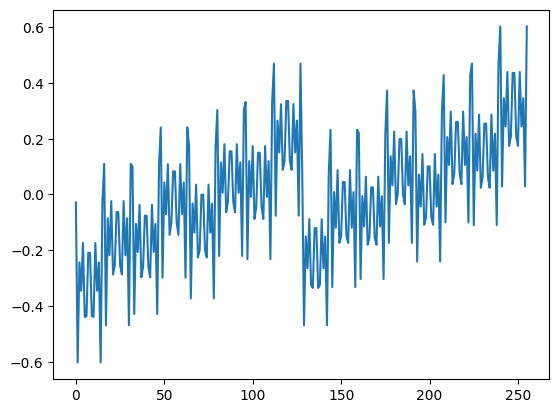

In [8]:
key4 = np.load('key3.npy')
A4 = [0] * 16
B4 = [0] * 16
HW = [(bin(n)).count("1") for n in range(0, 131072)]
HW_u4 = []
u_hyp4 = [] #for key varying from(0-256)
HW_u_hyp4 = []
num4 = 100
iv4 = np.load('iv3.npy')
iv4 = np.array(iv4[:num4])
trace_array4 = np.load('traces_array3.npy')
trace_array4 = np.array(trace_array4[:num4])
u_captured4 = np.load('u_captured3.npy')
u_captured4 = np.array(u_captured4[:num4])
for j1 in range(num4):
    for i1 in range(8):
        B4[i1]     = 0x0000
        B4[i1 + 8] = MAKEU16(key4[2 * i1 + 17], key4[2 * i1 + 16])
        
B4 = np.array(B4)
for j1 in range(num4):
    for i1 in range(8):
        A4[i1]     = MAKEU16(iv4[j1][2 * i1 + 1], iv4[j1][2 * i1])
        A4[i1 + 8] = MAKEU16(key4[2 * i1 + 1], key4[2 * i1])
    A4 = np.array(A4)

for u1 in u_captured4:
    HW_u4.append(HW[u1])
    
for j1 in range(num4):
    sub_u_hyp4 = []
    for A4[8] in range(0, 256):
        for i1 in range(8):
            A4[i1] = MAKEU16(iv4[j1][2 * i1 + 1], iv4[j1][2 * i1])
            #B[i] = 0x0000
        sub_u_hyp4.append(mul_x(A4[0], 0x990f) ^ A4[1] ^ mul_x_inv(A4[8], 0xcc87) ^ B4[0])    
    u_hyp4.append(sub_u_hyp4)
print("size of u_hyp",np.shape(u_hyp4))

for m in range(len(u_hyp4)):
    sub_HW_u_hyp4 = []
    for s in range(256):
        sub_HW_u_hyp4.append(('{0:08b}'.format(u_hyp4[m][s])[::-1][0:7]).count("1")) #Hamming weight of 1000 u [0:7] lower bits
    HW_u_hyp4.append(sub_HW_u_hyp4)
print("size of HW_u_hyp", np.shape(HW_u_hyp4))

samples_per_trace4 = np.shape(HW_u_hyp4)[1]
num_traces4 = np.shape(HW_u_hyp4)[0]

plt.figure()
hyp_pwr4 = np.array(HW_u4).reshape(-1,1)

traces_hyp_pwr4 = np.concatenate((HW_u_hyp4,hyp_pwr4), axis = 1)
    
correlation4 = np.corrcoef(traces_hyp_pwr4.T)
corr4 = correlation4[samples_per_trace4, :samples_per_trace4]
plt.plot(corr4)
plt.show()

size of u_hyp (250, 256)
size of HW_u_hyp (250, 256)


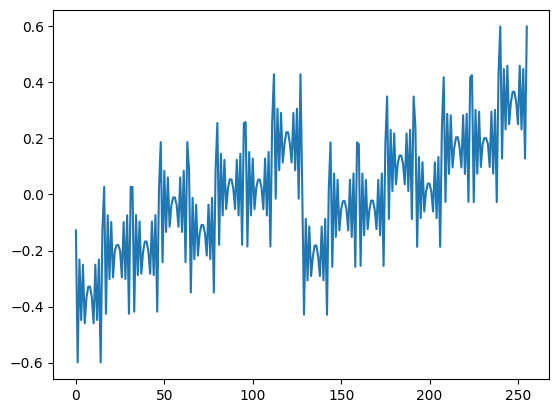

In [9]:
key5 = np.load('key3.npy')
A5 = [0] * 16
B5 = [0] * 16
HW = [(bin(n)).count("1") for n in range(0, 131072)]
HW_u5 = []
u_hyp5 = [] #for key varying from(0-256)
HW_u_hyp5 = []
num5 = 250
iv5 = np.load('iv3.npy')
iv5 = np.array(iv5[:num5])
trace_array5 = np.load('traces_array3.npy')
trace_array5 = np.array(trace_array5[:num5])
u_captured5 = np.load('u_captured3.npy')
u_captured5 = np.array(u_captured5[:num5])
for j1 in range(num5):
    for i1 in range(8):
        B5[i1]     = 0x0000
        B5[i1 + 8] = MAKEU16(key5[2 * i1 + 17], key5[2 * i1 + 16])
        
B5 = np.array(B5)
for j1 in range(num5):
    for i1 in range(8):
        A5[i1]     = MAKEU16(iv5[j1][2 * i1 + 1], iv5[j1][2 * i1])
        A5[i1 + 8] = MAKEU16(key5[2 * i1 + 1], key5[2 * i1])
    A5 = np.array(A5)

for u1 in u_captured5:
    HW_u5.append(HW[u1])
    
for j1 in range(num5):
    sub_u_hyp5 = []
    for A5[8] in range(0, 256):
        for i1 in range(8):
            A5[i1] = MAKEU16(iv5[j1][2 * i1 + 1], iv5[j1][2 * i1])
            #B[i] = 0x0000
        sub_u_hyp5.append(mul_x(A5[0], 0x990f) ^ A5[1] ^ mul_x_inv(A5[8], 0xcc87) ^ B5[0])    
    u_hyp5.append(sub_u_hyp5)
print("size of u_hyp",np.shape(u_hyp5))

for m in range(len(u_hyp5)):
    sub_HW_u_hyp5 = []
    for s in range(256):
        sub_HW_u_hyp5.append(('{0:08b}'.format(u_hyp5[m][s])[::-1][0:7]).count("1")) #Hamming weight of 1000 u [0:7] lower bits
    HW_u_hyp5.append(sub_HW_u_hyp5)
print("size of HW_u_hyp", np.shape(HW_u_hyp5))

samples_per_trace5 = np.shape(HW_u_hyp5)[1]
num_traces5 = np.shape(HW_u_hyp5)[0]

plt.figure()
hyp_pwr5 = np.array(HW_u5).reshape(-1,1)

traces_hyp_pwr5 = np.concatenate((HW_u_hyp5,hyp_pwr5), axis = 1)
    
correlation5 = np.corrcoef(traces_hyp_pwr5.T)
corr5 = correlation5[samples_per_trace5, :samples_per_trace5]
plt.plot(corr5)
plt.show()

size of u_hyp (500, 256)
size of HW_u_hyp (500, 256)


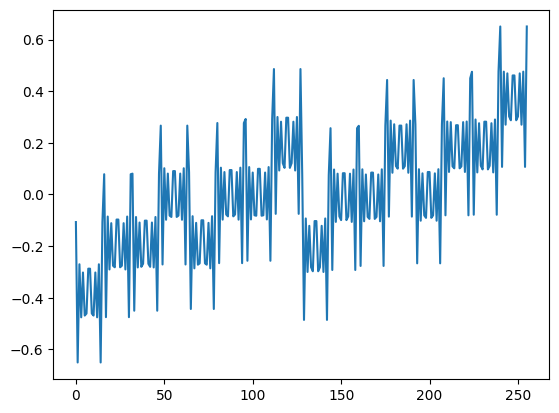

In [10]:
key6 = np.load('key3.npy')
A6 = [0] * 16
B6 = [0] * 16
HW = [(bin(n)).count("1") for n in range(0, 131072)]
HW_u6 = []
u_hyp6 = [] #for key varying from(0-256)
HW_u_hyp6 = []
num6 = 500
iv6 = np.load('iv3.npy')
iv6 = np.array(iv6[:num6])
trace_array6 = np.load('traces_array3.npy')
trace_array6 = np.array(trace_array6[:num6])
u_captured6 = np.load('u_captured3.npy')
u_captured6 = np.array(u_captured6[:num6])
for j1 in range(num6):
    for i1 in range(8):
        B6[i1]     = 0x0000
        B6[i1 + 8] = MAKEU16(key6[2 * i1 + 17], key6[2 * i1 + 16])
        
B6 = np.array(B6)
for j1 in range(num6):
    for i1 in range(8):
        A6[i1]     = MAKEU16(iv6[j1][2 * i1 + 1], iv6[j1][2 * i1])
        A6[i1 + 8] = MAKEU16(key6[2 * i1 + 1], key6[2 * i1])
    A6 = np.array(A6)

for u1 in u_captured6:
    HW_u6.append(HW[u1])
    
for j1 in range(num6):
    sub_u_hyp6 = []
    for A6[8] in range(0, 256):
        for i1 in range(8):
            A6[i1] = MAKEU16(iv6[j1][2 * i1 + 1], iv6[j1][2 * i1])
            #B[i] = 0x0000
        sub_u_hyp6.append(mul_x(A6[0], 0x990f) ^ A6[1] ^ mul_x_inv(A6[8], 0xcc87) ^ B6[0])    
    u_hyp6.append(sub_u_hyp6)
print("size of u_hyp",np.shape(u_hyp6))

for m in range(len(u_hyp6)):
    sub_HW_u_hyp6 = []
    for s in range(256):
        sub_HW_u_hyp6.append(('{0:08b}'.format(u_hyp6[m][s])[::-1][0:7]).count("1")) #Hamming weight of 1000 u [0:7] lower bits
    HW_u_hyp6.append(sub_HW_u_hyp6)
print("size of HW_u_hyp", np.shape(HW_u_hyp6))

samples_per_trace6 = np.shape(HW_u_hyp6)[1]
num_traces6 = np.shape(HW_u_hyp6)[0]

plt.figure()
hyp_pwr6 = np.array(HW_u6).reshape(-1,1)

traces_hyp_pwr6 = np.concatenate((HW_u_hyp6,hyp_pwr6), axis = 1)
    
correlation6 = np.corrcoef(traces_hyp_pwr6.T)
corr6 = correlation6[samples_per_trace6, :samples_per_trace6]
plt.plot(corr6)
plt.show()

size of u_hyp (1000, 256)
size of HW_u_hyp (1000, 256)


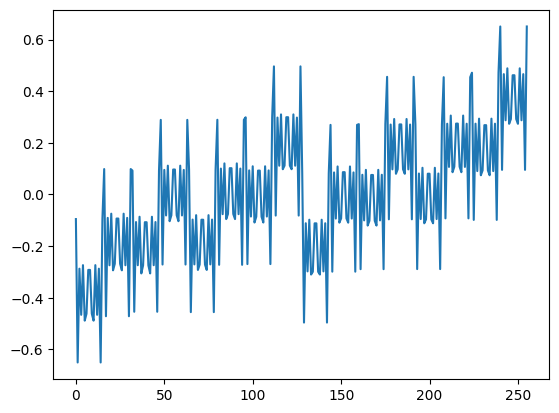

In [11]:
key7 = np.load('key3.npy')
A7 = [0] * 16
B7 = [0] * 16
HW = [(bin(n)).count("1") for n in range(0, 131072)]
HW_u7 = []
u_hyp7 = [] #for key varying from(0-256)
HW_u_hyp7 = []
num7 = 1000
iv7 = np.load('iv3.npy')
iv7 = np.array(iv7[:num7])
trace_array7 = np.load('traces_array3.npy')
trace_array7 = np.array(trace_array7[:num7])
u_captured7 = np.load('u_captured3.npy')
u_captured7 = np.array(u_captured7[:num7])
for j1 in range(num7):
    for i1 in range(8):
        B7[i1]     = 0x0000
        B7[i1 + 8] = MAKEU16(key7[2 * i1 + 17], key7[2 * i1 + 16])
        
B7 = np.array(B7)
for j1 in range(num7):
    for i1 in range(8):
        A7[i1]     = MAKEU16(iv7[j1][2 * i1 + 1], iv7[j1][2 * i1])
        A7[i1 + 8] = MAKEU16(key7[2 * i1 + 1], key7[2 * i1])
    A7 = np.array(A7)

for u1 in u_captured7:
    HW_u7.append(HW[u1])
    
for j1 in range(num7):
    sub_u_hyp7 = []
    for A7[8] in range(0, 256):
        for i1 in range(8):
            A7[i1] = MAKEU16(iv7[j1][2 * i1 + 1], iv7[j1][2 * i1])
            #B[i] = 0x0000
        sub_u_hyp7.append(mul_x(A7[0], 0x990f) ^ A7[1] ^ mul_x_inv(A7[8], 0xcc87) ^ B7[0])    
    u_hyp7.append(sub_u_hyp7)
print("size of u_hyp",np.shape(u_hyp7))

for m in range(len(u_hyp7)):
    sub_HW_u_hyp7 = []
    for s in range(256):
        sub_HW_u_hyp7.append(('{0:08b}'.format(u_hyp7[m][s])[::-1][0:7]).count("1")) #Hamming weight of 1000 u [0:7] lower bits
    HW_u_hyp7.append(sub_HW_u_hyp7)
print("size of HW_u_hyp", np.shape(HW_u_hyp7))

samples_per_trace7 = np.shape(HW_u_hyp7)[1]
num_traces7 = np.shape(HW_u_hyp7)[0]

plt.figure()
hyp_pwr7 = np.array(HW_u7).reshape(-1,1)

traces_hyp_pwr7 = np.concatenate((HW_u_hyp7,hyp_pwr7), axis = 1)
    
correlation7 = np.corrcoef(traces_hyp_pwr7.T)
corr7 = correlation7[samples_per_trace7, :samples_per_trace7]
plt.plot(corr7)
plt.show()

size of u_hyp (2500, 256)
size of HW_u_hyp (2500, 256)


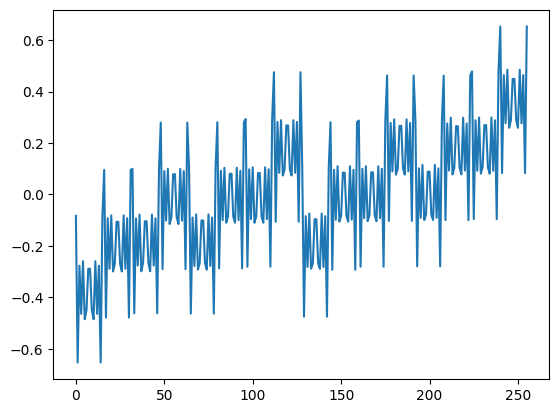

In [12]:
key8 = np.load('key3.npy')
A8 = [0] * 16
B8 = [0] * 16
HW = [(bin(n)).count("1") for n in range(0, 131072)]
HW_u8 = []
u_hyp8 = [] #for key varying from(0-256)
HW_u_hyp8 = []
num8 = 2500
iv8 = np.load('iv3.npy')
iv8 = np.array(iv8[:num8])
trace_array8 = np.load('traces_array3.npy')
trace_array8 = np.array(trace_array8[:num8])
u_captured8 = np.load('u_captured3.npy')
u_captured8 = np.array(u_captured8[:num8])
for j1 in range(num8):
    for i1 in range(8):
        B8[i1]     = 0x0000
        B8[i1 + 8] = MAKEU16(key8[2 * i1 + 17], key8[2 * i1 + 16])
        
B8 = np.array(B8)
for j1 in range(num8):
    for i1 in range(8):
        A8[i1]     = MAKEU16(iv8[j1][2 * i1 + 1], iv8[j1][2 * i1])
        A8[i1 + 8] = MAKEU16(key8[2 * i1 + 1], key8[2 * i1])
    A8 = np.array(A8)

for u1 in u_captured8:
    HW_u8.append(HW[u1])
    
for j1 in range(num8):
    sub_u_hyp8 = []
    for A8[8] in range(0, 256):
        for i1 in range(8):
            A8[i1] = MAKEU16(iv8[j1][2 * i1 + 1], iv8[j1][2 * i1])
            #B[i] = 0x0000
        sub_u_hyp8.append(mul_x(A8[0], 0x990f) ^ A8[1] ^ mul_x_inv(A8[8], 0xcc87) ^ B8[0])    
    u_hyp8.append(sub_u_hyp8)
print("size of u_hyp",np.shape(u_hyp8))

for m in range(len(u_hyp8)):
    sub_HW_u_hyp8 = []
    for s in range(256):
        sub_HW_u_hyp8.append(('{0:08b}'.format(u_hyp8[m][s])[::-1][0:7]).count("1")) #Hamming weight of 1000 u [0:7] lower bits
    HW_u_hyp8.append(sub_HW_u_hyp8)
print("size of HW_u_hyp", np.shape(HW_u_hyp8))

samples_per_trace8 = np.shape(HW_u_hyp8)[1]
num_traces8 = np.shape(HW_u_hyp8)[0]

plt.figure()
hyp_pwr8 = np.array(HW_u8).reshape(-1,1)

traces_hyp_pwr8 = np.concatenate((HW_u_hyp8,hyp_pwr8), axis = 1)
    
correlation8 = np.corrcoef(traces_hyp_pwr8.T)
corr8 = correlation8[samples_per_trace8, :samples_per_trace8]
plt.plot(corr8)
plt.show()

size of u_hyp (10000, 256)
size of HW_u_hyp (10000, 256)


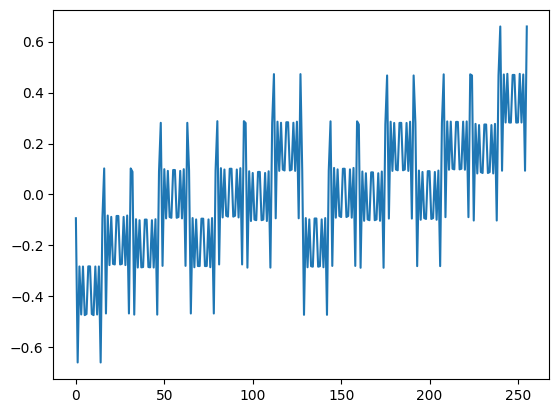

In [13]:
key9 = np.load('key3.npy')
A9 = [0] * 16
B9 = [0] * 16
HW = [(bin(n)).count("1") for n in range(0, 131072)]
HW_u9 = []
u_hyp9 = [] #for key varying from(0-256)
HW_u_hyp9 = []
num9 = 10000
iv9 = np.load('iv3.npy')
iv9 = np.array(iv9[:num9])
trace_array9 = np.load('traces_array3.npy')
trace_array9 = np.array(trace_array9[:num9])
u_captured9 = np.load('u_captured3.npy')
u_captured9 = np.array(u_captured9[:num9])
for j1 in range(num9):
    for i1 in range(8):
        B9[i1]     = 0x0000
        B9[i1 + 8] = MAKEU16(key9[2 * i1 + 17], key9[2 * i1 + 16])
        
B9 = np.array(B9)
for j1 in range(num9):
    for i1 in range(8):
        A9[i1]     = MAKEU16(iv9[j1][2 * i1 + 1], iv9[j1][2 * i1])
        A9[i1 + 8] = MAKEU16(key9[2 * i1 + 1], key9[2 * i1])
    A9 = np.array(A9)

for u1 in u_captured9:
    HW_u9.append(HW[u1])
    
for j1 in range(num9):
    sub_u_hyp9 = []
    for A9[8] in range(0, 256):
        for i1 in range(8):
            A9[i1] = MAKEU16(iv9[j1][2 * i1 + 1], iv9[j1][2 * i1])
            #B[i] = 0x0000
        sub_u_hyp9.append(mul_x(A9[0], 0x990f) ^ A9[1] ^ mul_x_inv(A9[8], 0xcc87) ^ B9[0])    
    u_hyp9.append(sub_u_hyp9)
print("size of u_hyp",np.shape(u_hyp9))

for m in range(len(u_hyp9)):
    sub_HW_u_hyp9 = []
    for s in range(256):
        sub_HW_u_hyp9.append(('{0:08b}'.format(u_hyp9[m][s])[::-1][0:7]).count("1")) #Hamming weight of 1000 u [0:7] lower bits
    HW_u_hyp9.append(sub_HW_u_hyp9)
print("size of HW_u_hyp", np.shape(HW_u_hyp9))

samples_per_trace9 = np.shape(HW_u_hyp9)[1]
num_traces9 = np.shape(HW_u_hyp9)[0]

plt.figure()
hyp_pwr9 = np.array(HW_u9).reshape(-1,1)

traces_hyp_pwr9 = np.concatenate((HW_u_hyp9,hyp_pwr9), axis = 1)
    
correlation9 = np.corrcoef(traces_hyp_pwr9.T)
corr9 = correlation9[samples_per_trace9, :samples_per_trace9]
plt.plot(corr9)
plt.show()

In [14]:
corr = np.array([corr1, corr2, corr3, corr4, corr5, corr6, corr7, corr8, corr9])
corr = ((corr))
print(np.shape(corr))

(9, 256)


In [15]:
sa=[0.22041550751119357,0.44449112733354396]
for l in range(2,9):
    sa.append(max(corr[l]))
print(sa)   

[0.22041550751119357, 0.44449112733354396, 0.6028094120502876, 0.602626613180987, 0.5994506711645454, 0.6504239522838438, 0.6505886329146999, 0.653579934632987, 0.659205584895741]


In [16]:
sm=[-0.22041550751119357,-0.44449112733354396]
for l in range(2,9):
    sm.append(min(corr[l]))
print(sm)   

[-0.22041550751119357, -0.44449112733354396, -0.6028094120502876, -0.602626613180987, -0.5994506711645454, -0.6504239522838438, -0.6505886329146999, -0.653579934632987, -0.659205584895741]


In [17]:
num = np.array([num1, num2, num3, num4, num5, num6, num7, num8, num9])

In [18]:
print(np.shape(num))

(9,)


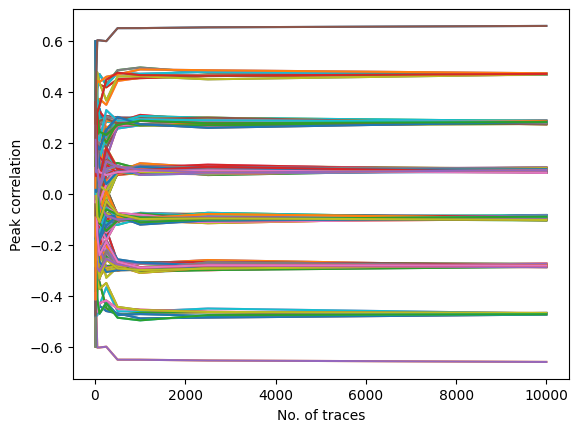

In [19]:
plt.plot(num,corr)
plt.xlabel('No. of traces')
plt.ylabel('Peak correlation')
plt.show()

In [ ]:
y=[0,1,2,3,4,5,6,7,8]
x = range(len(num-1))
fig, ax = plt.subplots()
ax.plot(x,corr, color = 'grey')
ax.plot(y,sm, color = 'grey',label="incorrect keys")
ax.plot(y,sa, marker ='o', color = 'red',label="correct key")
ax.plot(y,sm, marker = 'o', color = 'blue',label="ghost peaks for incorrect keys")
leg = ax.legend(loc ="upper left");
plt.xlabel('No. of traces')
plt.ylabel('Peak correlation')
plt.xticks(x, num)
plt.ylim([-1,1.2])
plt.savefig('mtd_final.svg')
plt.show()

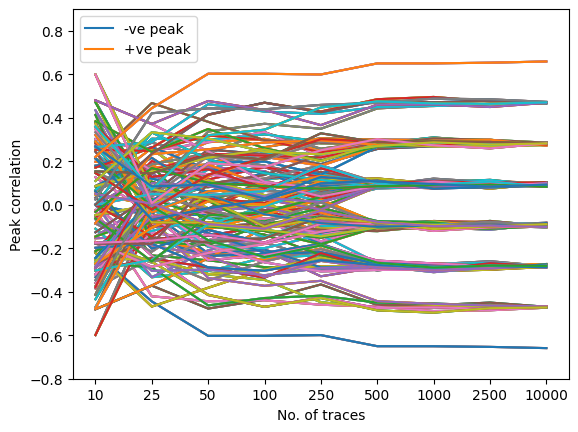

In [55]:
x = range(len(num))
for color in ['blue','green']:
    plt.plot(x,corr)
plt.xlabel('No. of traces')
plt.ylabel('Peak correlation')
plt.legend(["-ve peak", "+ve peak"], loc ="upper left")
plt.xticks(x, num)
plt.ylim([-0.8, 0.9])
plt.show()